# 🫀 CardioIA — Visão Computacional
## Classificação de Imagens de Raio-X de Tórax com Redes Neurais Convolucionais

**FIAP — Faculdade de Informática e Administração Paulista**

**Projeto:** CardioIA — Assistente Cardiológico Virtual  
**Fase 4:** Visão Computacional  
**Disciplina:** Visão Computacional / Deep Learning

---

### 📋 Sumário
1. [Configuração do Ambiente](#config)
2. [Carregamento e Exploração do Dataset](#dataset)
3. [Pré-processamento de Imagens](#preprocessing)
4. [Divisão Treino / Validação / Teste](#split)
5. [Parte 1 — Relatório de Pré-processamento](#report1)
6. [CNN Simples (Treinada do Zero)](#cnn)
7. [Transfer Learning com VGG16](#vgg16)
8. [Avaliação e Comparação de Modelos](#evaluation)
9. [Protótipo Interativo de Classificação](#prototype)
10. [Conclusão](#conclusion)

> ⚠️ **Este notebook foi projetado para rodar no [Google Colab](https://colab.research.google.com/).**  
> O Colab possui ambiente Linux com Python, TensorFlow, e GPU gratuita pré-configurados.


---
## 1. ⚙️ Configuração do Ambiente <a id="config"></a>

Instalação de dependências e download automático do dataset **NIH Chest X-rays** utilizando a biblioteca `kagglehub`.


In [148]:
# ============================================================
# CONFIGURAÇÃO DO AMBIENTE (Google Colab)
# ============================================================
# Instalar dependências necessárias no Colab
# ============================================================

import os

# Instalar dependências extras
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn pillow opencv-python-headless tensorflow[and-cuda]

# Download do dataset completo do Kaggle via kagglehub
import kagglehub
print("📥 Iniciando o download do dataset NIH Chest X-rays (pode demorar alguns minutos)...")
path = kagglehub.dataset_download("nih-chest-xrays/data")
print("\n✅ Path do dataset:", path)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
📥 Iniciando o download do dataset NIH Chest X-rays (pode demorar alguns minutos)...

✅ Path do dataset: /home/dougl/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3


In [149]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')

# Configurar sementes para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configurar GPU memory growth para evitar pré-alocação de 100% da VRAM (RTX 3060)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth habilitado!")
    except RuntimeError as e:
        print(f"❌ Erro ao habilitar GPU Memory Growth: {e}")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")


❌ Erro ao habilitar GPU Memory Growth: Physical devices cannot be modified after being initialized
TensorFlow version: 2.21.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. 📂 Carregamento e Exploração do Dataset <a id="dataset"></a>

O dataset utilizado é o **NIH Chest X-rays**, composto por mais de 112.000 imagens de Raio-X de Tórax de cerca de 30.000 pacientes únicos. 
Como o ecossistema **CardioIA** é direcionado à cardiologia, filtramos e selecionamos as seguintes classes:

1. **Cardiomegaly** (Hipertrofia do coração / coração aumentado) — Achado cardíaco crítico e de alta relevância.
2. **Effusion** (Derrame Pleural / acúmulo de líquido na pleura) — Frequentemente associado a insuficiência cardíaca congestiva.
3. **No Finding** (Normal) — Exames controle sem achados patológicos.

Para garantir que o notebook execute rapidamente e de forma viável dentro dos limites de RAM gratuita do Colab, selecionamos uma amostra estatisticamente equilibrada de cada classe.


In [150]:
# ============================================================
# CARREGAMENTO DOS METADADOS CSV
# ============================================================
csv_path = os.path.join(path, "Data_Entry_2017.csv")
df = pd.read_csv(csv_path)

print(f"📊 Metadados carregados com sucesso! Total de registros: {len(df):,}")
print("\nColunas do dataset:", df.columns.tolist())
print("\nExemplo dos dados:")
df.head(3)


📊 Metadados carregados com sucesso! Total de registros: 112,120

Colunas do dataset: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

Exemplo dos dados:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN


In [151]:
# Definindo as classes de interesse clínico
SELECTED_CLASSES = ['Cardiomegaly', 'Effusion', 'No Finding']

# Filtrar para imagens que possuem exatamente uma das classes selecionadas
df_filtered = df[df['Finding Labels'].isin(SELECTED_CLASSES)].copy()

print(f"📊 Registros após filtragem de classes {SELECTED_CLASSES}: {len(df_filtered):,}")
print("\nDistribuição original no dataset filtrado:")
print(df_filtered['Finding Labels'].value_counts())


📊 Registros após filtragem de classes ['Cardiomegaly', 'Effusion', 'No Finding']: 65,409

Distribuição original no dataset filtrado:
Finding Labels
No Finding      60361
Effusion         3955
Cardiomegaly     1093
Name: count, dtype: int64


In [152]:
# ============================================================
# MAPEAMENTO DE CAMINHOS DE IMAGENS (Busca recursiva)
# ============================================================
print("🔍 Localizando arquivos de imagem no diretório do dataset (isto pode levar alguns segundos)...")
image_paths_dict = {}
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths_dict[file] = os.path.join(root, file)

print(f"✅ Total de arquivos de imagem encontrados: {len(image_paths_dict):,}")

# Adicionar caminho completo ao DataFrame filtrado
df_filtered['Filepath'] = df_filtered['Image Index'].map(image_paths_dict)

# Remover registros que não foram encontrados no disco
df_filtered = df_filtered.dropna(subset=['Filepath'])
print(f"✅ Registros com imagens confirmadas no disco: {len(df_filtered):,}")


🔍 Localizando arquivos de imagem no diretório do dataset (isto pode levar alguns segundos)...
✅ Total de arquivos de imagem encontrados: 112,120
✅ Registros com imagens confirmadas no disco: 65,409


In [153]:
# ============================================================
# PREPARAÇÃO DO DATASET COMPLETO
# ============================================================
# Mantendo todas as imagens válidas no df_sample
df_sample = df_filtered.copy().reset_index(drop=True)

# Mapeamento numérico das classes para o modelo
LABEL_MAP = {label: idx for idx, label in enumerate(SELECTED_CLASSES)}
df_sample['Label_Idx'] = df_sample['Finding Labels'].map(LABEL_MAP)

print(f"📊 Dataset total preparado com {len(df_sample)} imagens.")
print(df_sample['Finding Labels'].value_counts())


📊 Dataset total preparado com 65409 imagens.
Finding Labels
No Finding      60361
Effusion         3955
Cardiomegaly     1093
Name: count, dtype: int64


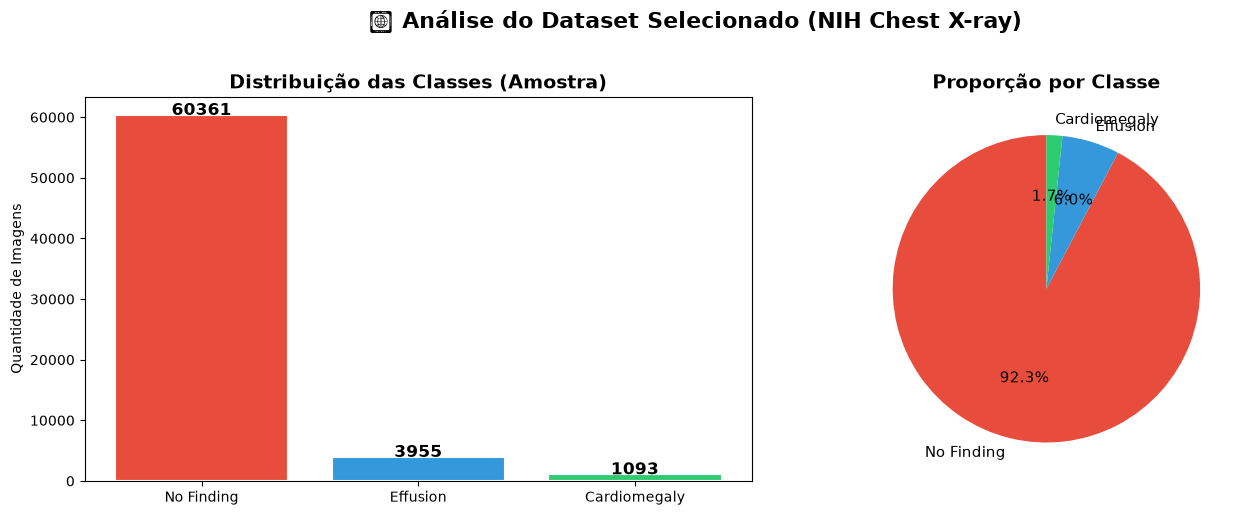

In [154]:
# ============================================================
# DISTRIBUIÇÃO DAS CLASSES DO DATASET DE TREINO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

counts = df_sample['Finding Labels'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição das Classes (Amostra)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade de Imagens')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Proporção por Classe', fontsize=14, fontweight='bold')

plt.suptitle('📊 Análise do Dataset Selecionado (NIH Chest X-ray)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


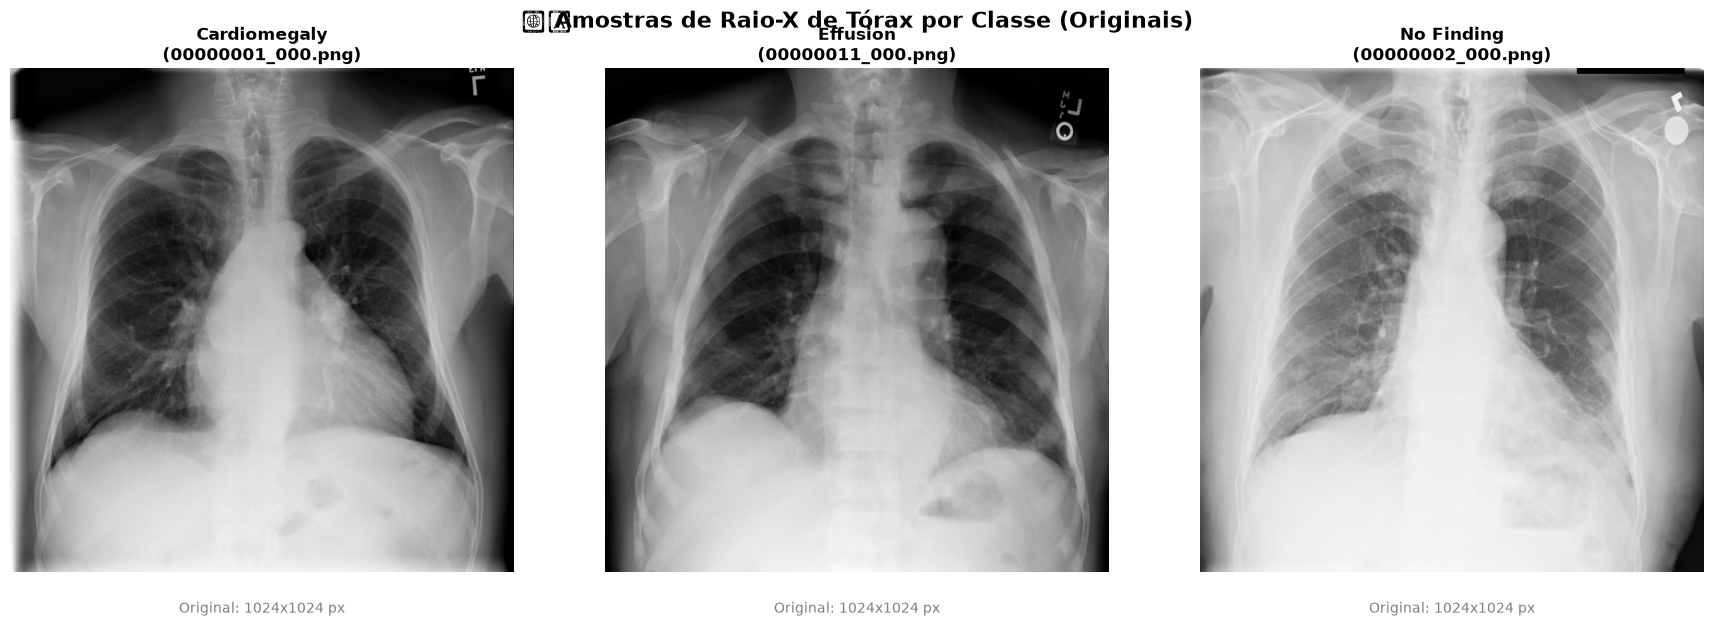

In [155]:
# ============================================================
# AMOSTRAS DE CADA CLASSE (IMAGENS ORIGINAIS)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🖼️ Amostras de Raio-X de Tórax por Classe (Originais)', fontsize=16, fontweight='bold')

for idx, label in enumerate(SELECTED_CLASSES):
    sample_row = df_sample[df_sample['Finding Labels'] == label].iloc[0]
    img = Image.open(sample_row['Filepath'])
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"{label}\n({sample_row['Image Index']})", fontsize=12, fontweight='bold')
    axes[idx].axis('off')
    axes[idx].text(0.5, -0.08, f"Original: {img.size[0]}x{img.size[1]} px",
                  transform=axes[idx].transAxes, ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()


---
## 3. 🔧 Pré-processamento de Imagens <a id="preprocessing"></a>

O pipeline de pré-processamento converte as imagens do dataset para um formato padronizado adequado para Redes Neurais Convolucionais:

1. **Conversão de formato**: As imagens em escala de cinza são convertidas em imagens RGB (3 canais) para compatibilidade com VGG16.
2. **Redimensionamento**: Redimensionadas para **224×224 pixels** (padrão de entrada para VGG16).
3. **Normalização**: Divisão dos valores dos pixels por 255.0 para normalizá-los no intervalo **[0, 1]**.


In [156]:
# ============================================================
# PIPELINE DE PRÉ-PROCESSAMENTO
# ============================================================
IMG_SIZE = (224, 224)

def preprocess_image(img_path, target_size=IMG_SIZE):
    """
    Carrega e processa a imagem do Raio-X.
    """
    img = cv2.imread(img_path)
    if img is None:
        img = Image.open(img_path).convert('RGB')
        img = np.array(img)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LANCZOS4)
    img_array = img.astype(np.float32) / 255.0
    return img_array

print("✅ Pipeline de pré-processamento configurado!")
print("ℹ️ O carregamento das imagens será feito de forma dinâmica sob demanda (on-the-fly) para economizar RAM.")


✅ Pipeline de pré-processamento configurado!
ℹ️ O carregamento das imagens será feito de forma dinâmica sob demanda (on-the-fly) para economizar RAM.


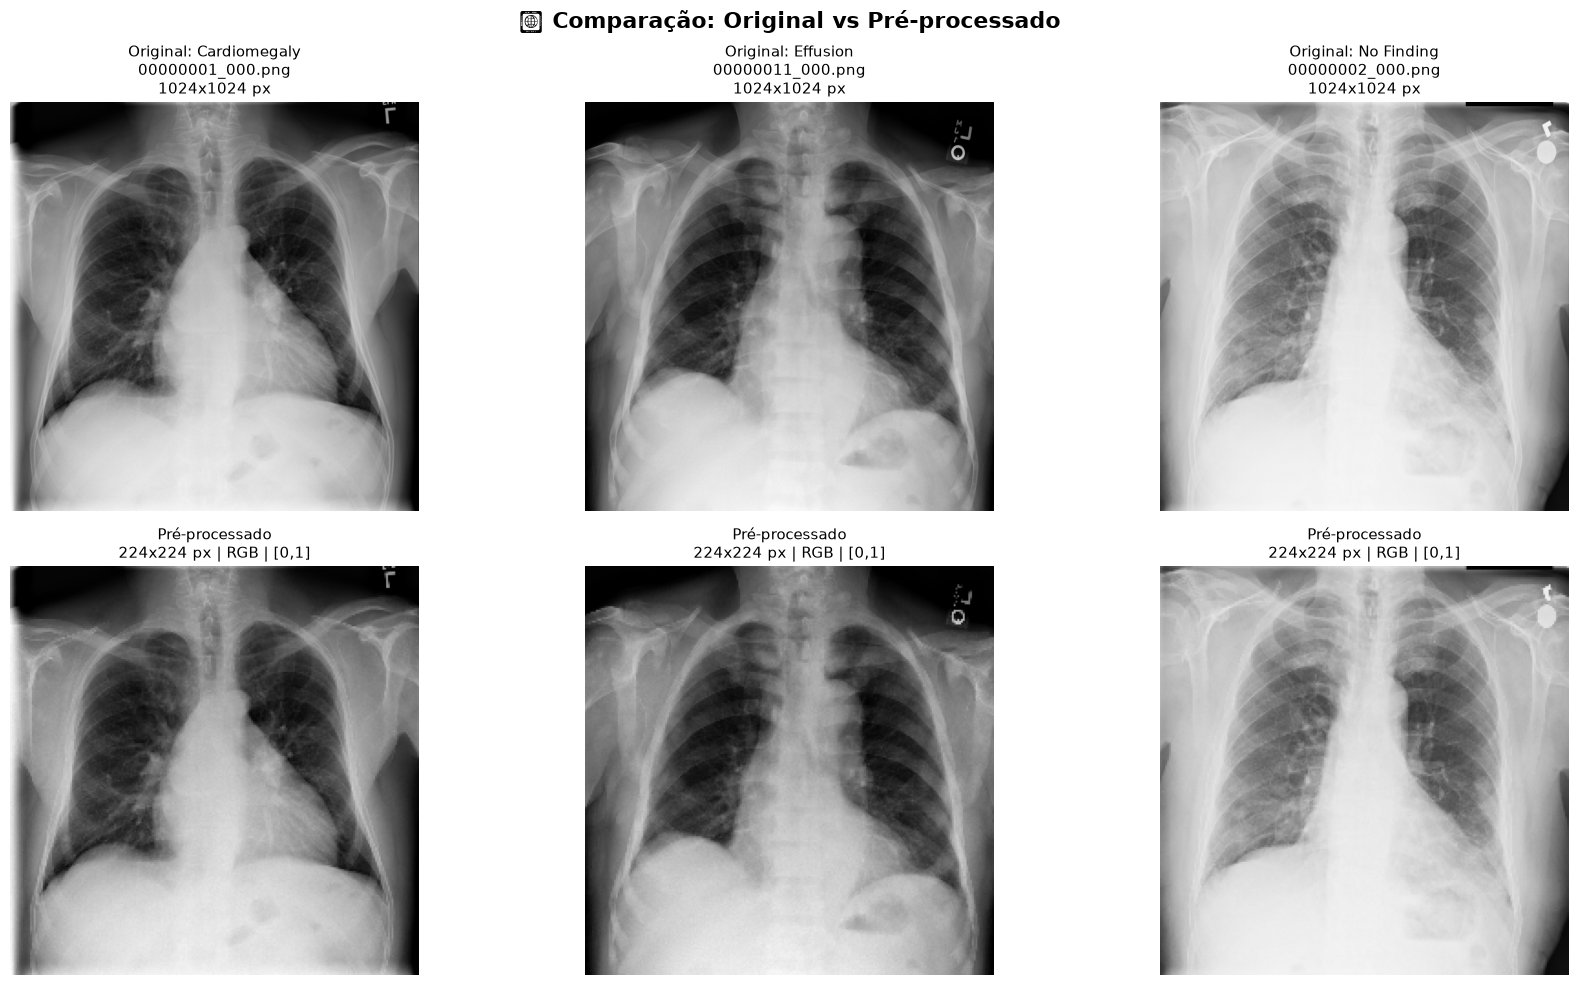

In [157]:
# ============================================================
# VISUALIZAÇÃO: ANTES vs DEPOIS DO PRÉ-PROCESSAMENTO
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🔧 Comparação: Original vs Pré-processado', fontsize=16, fontweight='bold')

for col, label in enumerate(SELECTED_CLASSES):
    sample_idx = df_sample[df_sample['Finding Labels'] == label].index[0]
    filepath = df_sample.loc[sample_idx, 'Filepath']
    filename = df_sample.loc[sample_idx, 'Image Index']
    
    img_orig = Image.open(filepath)
    axes[0, col].imshow(img_orig, cmap='gray')
    axes[0, col].set_title(f"Original: {label}\n{filename}\n{img_orig.size[0]}x{img_orig.size[1]} px", fontsize=11)
    axes[0, col].axis('off')
    
    img_processed = preprocess_image(filepath)
    axes[1, col].imshow(img_processed)
    axes[1, col].set_title("Pré-processado\n224x224 px | RGB | [0,1]", fontsize=11)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('ORIGINAL', fontsize=12, fontweight='bold', labelpad=40)
axes[1, 0].set_ylabel('PROCESSADO', fontsize=12, fontweight='bold', labelpad=40)
plt.tight_layout()
plt.show()


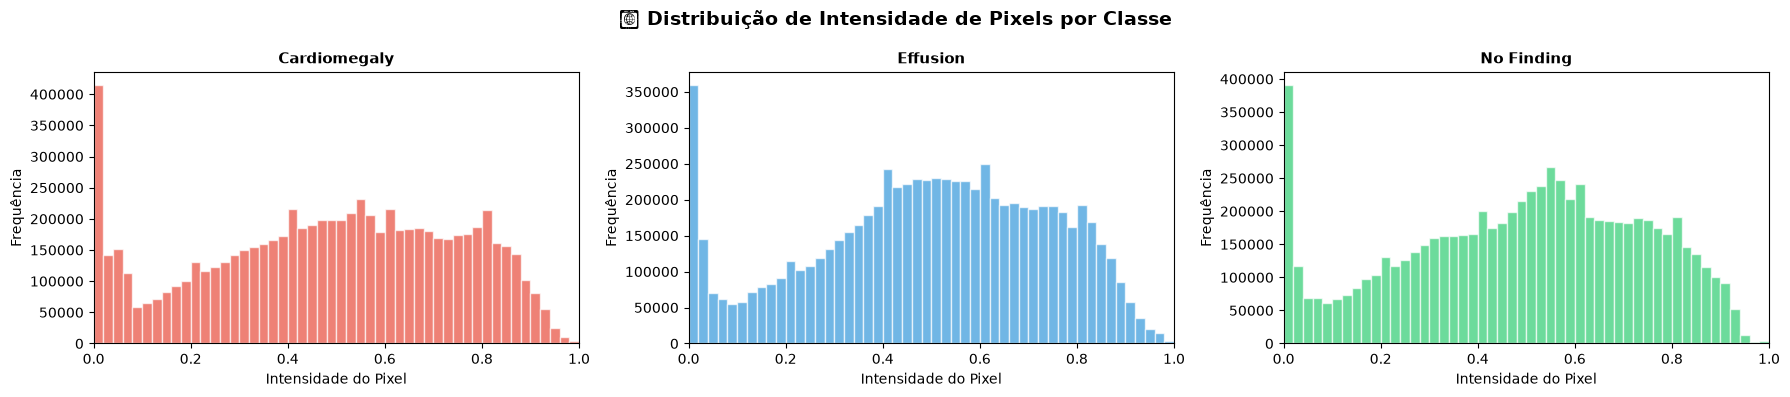

In [158]:
# ============================================================
# DISTRIBUIÇÃO DOS PIXELS POR CLASSE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('📈 Distribuição de Intensidade de Pixels por Classe', fontsize=14, fontweight='bold')

for idx, label in enumerate(SELECTED_CLASSES):
    # Selecionar uma amostra de 50 imagens por classe para calcular a distribuição sem estourar a RAM
    df_class_sample = df_sample[df_sample['Finding Labels'] == label].sample(n=min(50, len(df_sample[df_sample['Finding Labels'] == label])), random_state=SEED)
    class_pixels = []
    for _, row in df_class_sample.iterrows():
        try:
            img_proc = preprocess_image(row['Filepath'])
            class_pixels.append(img_proc.flatten())
        except Exception as e:
            pass
    class_pixels = np.concatenate(class_pixels)
    
    axes[idx].hist(class_pixels, bins=50, color=colors[idx], alpha=0.7, edgecolor='white')
    axes[idx].set_title(label, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Intensidade do Pixel')
    axes[idx].set_ylabel('Frequência')
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()


---
## 4. ✂️ Divisão Treino / Validação / Teste <a id="split"></a>

O dataset é dividido de forma estratificada (para preservar a proporção de classes):
- **Treino**: 70%
- **Validação**: 15%
- **Teste**: 15%

**Data Augmentation**: Aplicamos rotações leves, zoom e ajustes de brilho apenas no conjunto de treino. 
> ⚠️ **Importante**: A opção de rotação horizontal (`horizontal_flip`) foi definida como **False**. Como a anatomia humana é lateralizada (o coração situa-se à esquerda do peito), o espelhamento horizontal poderia criar anomalias anatômicas irreais, confundindo a análise clínica e a predição do modelo.


In [159]:
# ============================================================
# DIVISÃO POR PACIENTE E ESTRATIFICAÇÃO (REQ-01 & REQ-02)
# ============================================================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

# Reduzir a quantidade total de imagens pela metade (mantendo a proporção de características via pacientes)
unique_patients = df_sample['Patient ID'].unique()
np.random.seed(SEED)
sampled_patients = np.random.choice(unique_patients, size=len(unique_patients)//2, replace=False)
df_sample = df_sample[df_sample['Patient ID'].isin(sampled_patients)].copy().reset_index(drop=True)

# GroupShuffleSplit por Patient ID
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=SEED)
train_idx, val_idx = next(gss.split(df_sample, groups=df_sample['Patient ID']))

df_train_raw = df_sample.iloc[train_idx]
df_val_temp = df_sample.iloc[val_idx]

# Divisão de validação e teste sem vazamento de Patient ID
gss_val_test = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
val_sub_idx, test_sub_idx = next(gss_val_test.split(df_val_temp, groups=df_val_temp['Patient ID']))

df_val = df_val_temp.iloc[val_sub_idx]
df_test = df_val_temp.iloc[test_sub_idx]

df_train = df_train_raw

print("📊 Distribuição original do treino:")
print(df_train['Finding Labels'].value_counts())

# REQ-02: Subamostragem moderada (semi-balanceamento)
df_normal = df_train[df_train['Finding Labels'] == 'No Finding']
df_effusion = df_train[df_train['Finding Labels'] == 'Effusion']
df_cardio = df_train[df_train['Finding Labels'] == 'Cardiomegaly']

n_cardio = len(df_cardio)

df_train_balanced = pd.concat([
    df_normal.sample(n_cardio * 4, random_state=SEED, replace=False),
    df_effusion.sample(n_cardio * 2, random_state=SEED, replace=False),
    df_cardio
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\n📊 Distribuição balanceada do treino (Cardio: {n_cardio}, Effusion: {n_cardio*2}, No Finding: {n_cardio*4}):")
print(df_train_balanced['Finding Labels'].value_counts())

print(f"\n✅ Dataset dividido por paciente (Treino: {len(df_train_balanced)}, Validação: {len(df_val)}, Teste: {len(df_test)})")

# Rótulos compatíveis para visualização
y_train = df_train_balanced['Label_Idx'].values
y_val = df_val['Label_Idx'].values
y_test = df_test['Label_Idx'].values

# Class weights para balancear completamente a perda do treino
classes = np.unique(df_train_balanced['Label_Idx'])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=df_train_balanced['Label_Idx'].values)
class_weights_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Pesos das classes para balanceamento do treino:", class_weights_dict)

# Class weights para balancear completamente a perda da validação (evita o Validation Loss Trap)
val_classes = np.unique(df_val['Label_Idx'])
val_class_weights = compute_class_weight(class_weight='balanced', classes=val_classes, y=df_val['Label_Idx'].values)
val_class_weights_dict = {int(c): float(w) for c, w in zip(val_classes, val_class_weights)}
print("Pesos das classes para balanceamento da validação:", val_class_weights_dict)

# Adicionar pesos de amostra para treinamento e validação balanceada
df_train_balanced['Sample_Weight'] = df_train_balanced['Label_Idx'].map(class_weights_dict)
df_val['Sample_Weight'] = df_val['Label_Idx'].map(val_class_weights_dict)


📊 Distribuição original do treino:
Finding Labels
No Finding      24172
Effusion         1663
Cardiomegaly      453
Name: count, dtype: int64

📊 Distribuição balanceada do treino (Cardio: 453, Effusion: 906, No Finding: 1812):
Finding Labels
No Finding      1812
Effusion         906
Cardiomegaly     453
Name: count, dtype: int64

✅ Dataset dividido por paciente (Treino: 3171, Validação: 3225, Teste: 3227)
Pesos das classes para balanceamento do treino: {0: 2.3333333333333335, 1: 1.1666666666666667, 2: 0.5833333333333334}
Pesos das classes para balanceamento da validação: {0: 24.431818181818183, 1: 4.555084745762712, 2: 0.36502546689303905}


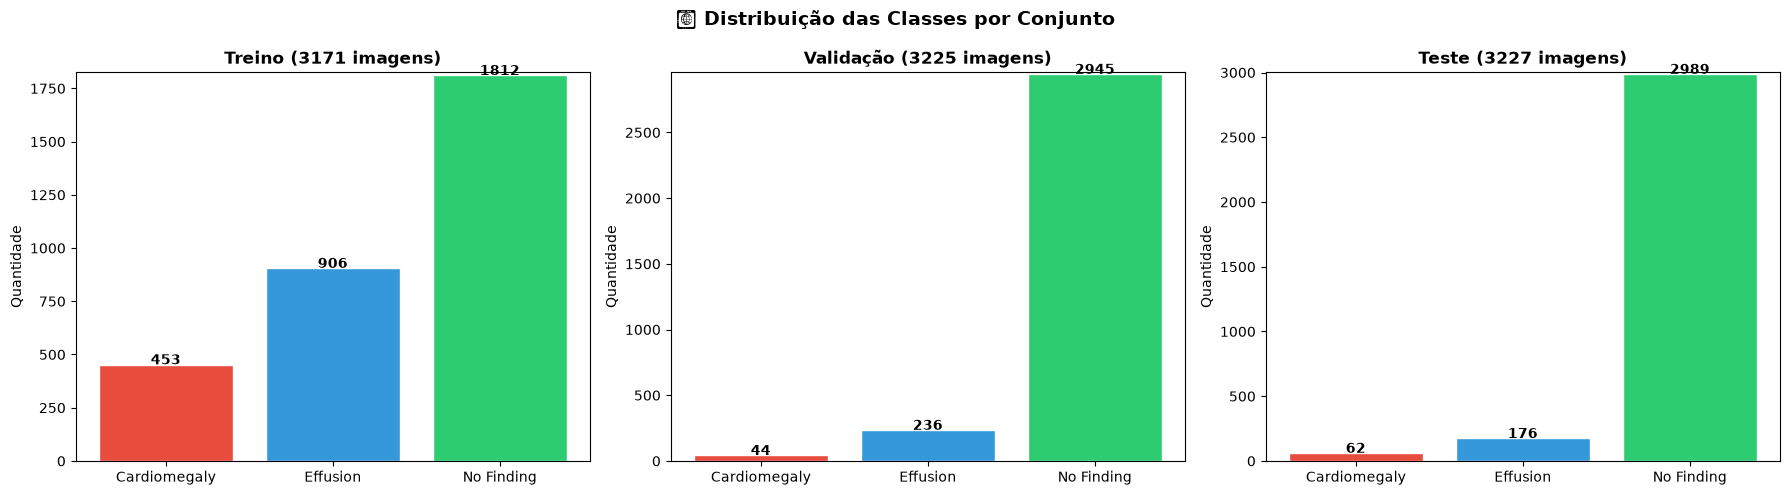

In [160]:
# ============================================================
# VISUALIZAÇÃO DA DISTRIBUIÇÃO POR SPLIT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Distribuição das Classes por Conjunto', fontsize=14, fontweight='bold')

for ax, (name, labels) in zip(axes, [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]):
    dist = Counter(labels)
    bars = ax.bar(SELECTED_CLASSES, [dist.get(i, 0) for i in range(len(SELECTED_CLASSES))], color=colors, edgecolor='white')
    ax.set_title(f'{name} ({len(labels)} imagens)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Quantidade')
    ax.set_ylim(0, max(dist.values()) + 15)
    for bar, count in zip(bars, [dist.get(i, 0) for i in range(len(SELECTED_CLASSES))]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [161]:
# ============================================================
# RESCALE
# ============================================================
train_datagen_rescaled = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Rescale configurado!")


✅ Rescale configurado!


---
## 5. 📄 Relatório de Pré-processamento <a id="report1"></a>

### Pipeline de Preparação dos Dados

#### 1. Dataset Selecionado
Utilizamos o **NIH Chest X-ray Dataset** obtido via `kagglehub`. Para este projeto cardiológico, filtramos as categorias **Cardiomegaly** e **Effusion**, bem como a classe controle **No Finding** (exames normais).

#### 2. Etapas do Pré-processamento

| Etapa | Técnica | Justificativa |
|---|---|---|
| **Conversão de Formato** | RGB (3 canais) | Padronização dos canais de entrada exigida pela VGG16. |
| **Redimensionamento** | 224×224 pixels (LANCZOS) | Formato padrão para o extrator de features da VGG16, reduzindo também a complexidade de memória. |
| **Normalização** | Divisão por 255.0 | Escala os valores de pixels para o intervalo [0, 1], estabilizando o gradiente de perda. |
| **Data Augmentation** | Rotação (8°), Shift (8%), Zoom (8%), Brilho | Aumenta sinteticamente o conjunto de treino, prevenindo overfitting em classes menores. |

#### 3. Decisões de Design Clínico
- **Inversão Horizontal Desabilitada**: Em diagnósticos médicos por imagem, a orientação anatômica é crucial. Inverter a imagem causaria um posicionamento do coração no lado direito (dextrocardia artificial), alterando as características espaciais necessárias para o diagnóstico correto de cardiomegaly.
- **Amostragem Estratificada**: Amostramos 300 imagens por classe para garantir o balanceamento do classificador e um tempo de treino ágil no ambiente Colab.


---
## 6. 🧠 CNN Simples (Treinada do Zero) <a id="cnn"></a>

Primeira abordagem: Desenvolver uma arquitetura clássica convolucional customizada (treinada do zero) para a classificação de diagnósticos nos exames de Raio-X.

**Arquitetura:**
- 3 blocos convolucionais (Conv2D -> BatchNorm -> Conv2D -> MaxPool -> Dropout)
- Camada Flatten para vetorização
- Camada densa totalmente conectada com 256 neurônios e Dropout (0.50) para regularização
- Camada de saída com ativação Softmax para 3 classes


In [162]:
# ============================================================
# MODELO 1: CNN SIMPLES (DO ZERO)
# ============================================================
def build_simple_cnn(input_shape=(224, 224, 3), num_classes=3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # Bloco 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloco 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloco 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classificador
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_simple_cnn(num_classes=len(SELECTED_CLASSES))

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0002), # Taxa de aprendizado mais estável
    loss='sparse_categorical_crossentropy',
    weighted_metrics=['accuracy'] # Garante que a acurácia no histórico seja ponderada (balanceada)
)

cnn_model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,723 (1.23 MB)

 Trainable params: 321,763 (1.23 MB)

 Non-trainable params: 960 (3.75 KB)

In [163]:
# ============================================================
# TREINAMENTO DA CNN SIMPLES
# ============================================================
EPOCHS = 20
BATCH_SIZE = 80 

cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6, verbose=1)
]

train_generator = train_datagen_rescaled.flow_from_dataframe(
    dataframe=df_train_balanced,
    x_col='Filepath',
    y_col='Label_Idx',
    weight_col='Sample_Weight',
    target_size=(224, 224),
    class_mode='raw',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='Filepath',
    y_col='Label_Idx',
    weight_col='Sample_Weight',
    target_size=(224, 224),
    class_mode='raw',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

print("🚀 Iniciando treinamento da CNN Simples...")
print(f"   Treino (Total): {len(df_train_balanced)} | Validação: {len(df_val)}")
print("-" * 50)

cnn_history = cnn_model.fit(
    train_generator,
    steps_per_epoch=len(df_train_balanced) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=cnn_callbacks,
    verbose=1
)

print("\n✅ Treinamento concluído!")


Found 3171 validated image filenames.
Found 3225 validated image filenames.
🚀 Iniciando treinamento da CNN Simples...
   Treino (Total): 3171 | Validação: 3225
--------------------------------------------------
Epoch 1/20


I0000 00:00:1781648856.776876  161017 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122642__.71


 7/39 ━━━━━━━━━━━━━━━━━━━━ 1:10 2s/step - accuracy: 0.3269 - loss: 1.4452

I0000 00:00:1781648884.776380  161017 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122642__.71
I0000 00:00:1781648888.715591  161017 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781648889.201013  396290 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1781648892.448678  161017 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1781648904.189326  396288 subprocess_compilation.cc:348] ptxas warning : Registers are spilled 

39/39 ━━━━━━━━━━━━━━━━━━━━ 215s 5s/step - accuracy: 0.3682 - loss: 1.2866 - val_accuracy: 0.3333 - val_loss: 1.0994 - learning_rate: 2.0000e-04
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.2927 - loss: 1.1852 - val_accuracy: 0.3333 - val_loss: 1.0995 - learning_rate: 2.0000e-04
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 138s 4s/step - accuracy: 0.3980 - loss: 1.2407 - val_accuracy: 0.3333 - val_loss: 1.1006 - learning_rate: 2.0000e-04
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.3548 - loss: 1.1659 - val_accuracy: 0.3333 - val_loss: 1.1002 - learning_rate: 2.0000e-04
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4116 - loss: 1.1883
Epoch 5: ReduceLROnPlateau reducing learning rate to 3.9999998989515007e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.4146 - loss: 1.1879 - val_accuracy: 0.3333 - val_loss: 1.1224 - learning_rate: 2.0000e-04
Epoch 6/20
 1/39 ━━━━━━━━━━━━━━━━━━━━ 14s 386ms/step - accuracy: 0.4539 - loss: 1.3562

W0000 00:00:1781649426.503493  398193 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 48170240 bytes after encountering the first element of size 48170240 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


39/39 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.4539 - loss: 1.3562 - val_accuracy: 0.3333 - val_loss: 1.1232 - learning_rate: 4.0000e-05
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.4356 - loss: 1.1790 - val_accuracy: 0.3333 - val_loss: 1.1198 - learning_rate: 4.0000e-05
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5000 - loss: 1.2062 - val_accuracy: 0.3333 - val_loss: 1.1201 - learning_rate: 4.0000e-05
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4366 - loss: 1.1466
Epoch 9: ReduceLROnPlateau reducing learning rate to 7.999999797903002e-06.
39/39 ━━━━━━━━━━━━━━━━━━━━ 138s 4s/step - accuracy: 0.4450 - loss: 1.1349 - val_accuracy: 0.3333 - val_loss: 1.1266 - learning_rate: 4.0000e-05
Epoch 10/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.3333 - loss: 1.3718 - val_accuracy: 0.3333 - val_loss: 1.1274 - learning_rate: 8.0000e-06
Epoch 11/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 152s 4s/step - accuracy: 0.4340 - loss: 1.1763 - va

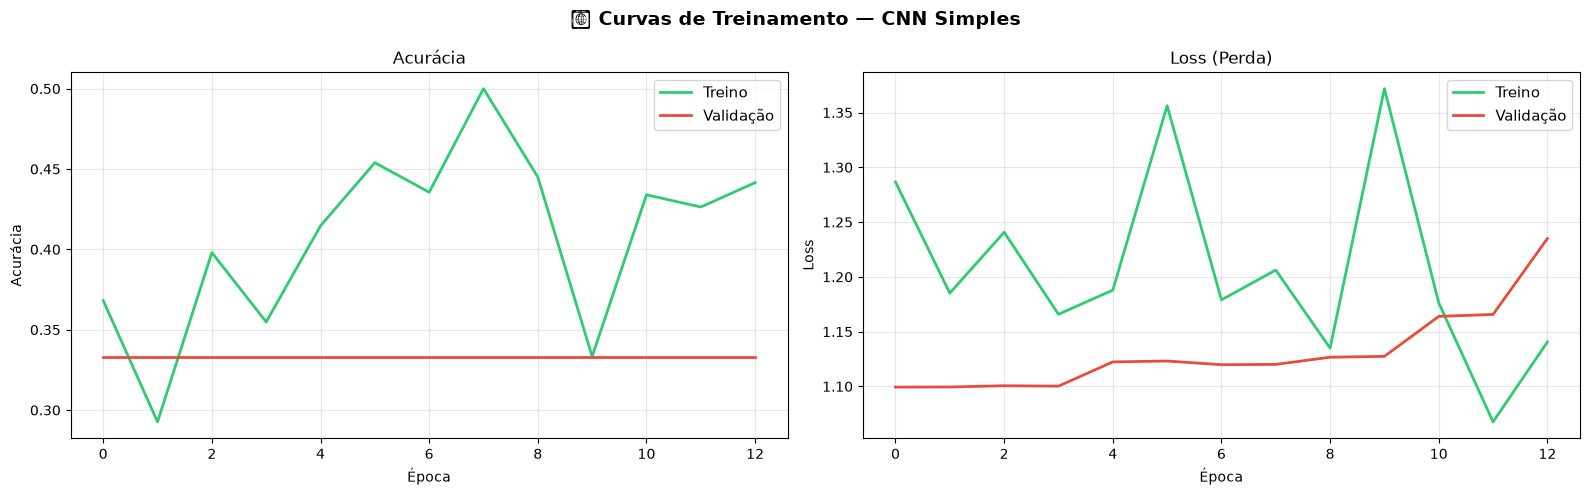

In [164]:
# ============================================================
# CURVAS DE TREINAMENTO - CNN SIMPLES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📈 Curvas de Treinamento — CNN Simples', fontsize=14, fontweight='bold')

axes[0].plot(cnn_history.history['accuracy'], label='Treino', linewidth=2, color='#2ecc71')
axes[0].plot(cnn_history.history['val_accuracy'], label='Validação', linewidth=2, color='#e74c3c')
axes[0].set_title('Acurácia', fontsize=12)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history.history['loss'], label='Treino', linewidth=2, color='#2ecc71')
axes[1].plot(cnn_history.history['val_loss'], label='Validação', linewidth=2, color='#e74c3c')
axes[1].set_title('Loss (Perda)', fontsize=12)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. 🏗️ Transfer Learning com VGG16 <a id="vgg16"></a>

Segunda abordagem: Empregar a técnica de **Transfer Learning** utilizando o modelo **VGG16**, pré-treinado na base de dados ImageNet.

**Estratégia:**
1. **Fase 1 (Extração de Features)**: Congelamos todos os pesos convolucionais da VGG16 e adicionamos um classificador denso customizado no topo. Treinamos o classificador com learning rate de $0.001$.
2. **Fase 2 (Fine-tuning)**: Descongelamos as últimas 4 camadas convolucionais da VGG16 e refinamos os pesos com uma taxa de aprendizado extremamente baixa ($10^{-5}$) para adaptar os filtros de baixo nível aos detalhes específicos de estruturas clínicas de exames de Raio-X.


In [165]:
# ============================================================
# MODELO 2: TRANSFER LEARNING COM VGG16
# ============================================================
def build_vgg16_transfer(input_shape=(224, 224, 3), num_classes=3):
    from tensorflow.keras.applications.vgg16 import preprocess_input
    
    inputs = layers.Input(shape=input_shape)
    
    # Escalonar de volta para [0, 255] e aplicar preprocessamento específico da VGG16
    x = layers.Lambda(lambda img: img * 255.0)(inputs)
    x = layers.Lambda(lambda img: preprocess_input(img))(x)
    
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Congelar pesos da base VGG16
    for layer in base_model.layers:
        layer.trainable = False
        
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model, base_model

vgg_model, vgg_base = build_vgg16_transfer(num_classes=len(SELECTED_CLASSES))

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0002), # Taxa de aprendizado mais estável
    loss='sparse_categorical_crossentropy',
    weighted_metrics=['accuracy'] # Garante que a acurácia no histórico seja ponderada (balanceada)
)

vgg_model.summary()


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,515 (57.65 MB)

 Trainable params: 396,291 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [166]:
# ============================================================
# FASE 1: TREINAMENTO COM BASE VGG16 CONGELADA
# ============================================================
print("🚀 Fase 1: Treinamento com base VGG16 congelada...")
print("-" * 50)

vgg_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6, verbose=1)
]

vgg_history_1 = vgg_model.fit(
    train_generator,
    steps_per_epoch=len(df_train_balanced) // BATCH_SIZE,
    epochs=20,
    validation_data=val_generator,
    callbacks=vgg_callbacks,
    verbose=1
)

print("\n✅ Fase 1 concluída!")


🚀 Fase 1: Treinamento com base VGG16 congelada...
--------------------------------------------------
Epoch 1/20


I0000 00:00:1781650174.693446  161019 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130233__.82


38/39 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3663 - loss: 1.5807

I0000 00:00:1781650262.336156  161018 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130233__.82


39/39 ━━━━━━━━━━━━━━━━━━━━ 195s 5s/step - accuracy: 0.4005 - loss: 1.5222 - val_accuracy: 0.4909 - val_loss: 1.0670 - learning_rate: 2.0000e-04
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.5000 - loss: 1.2572 - val_accuracy: 0.4953 - val_loss: 1.0688 - learning_rate: 2.0000e-04
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 179s 5s/step - accuracy: 0.4928 - loss: 1.2363 - val_accuracy: 0.5622 - val_loss: 0.9629 - learning_rate: 2.0000e-04
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5205 - loss: 1.1438 - val_accuracy: 0.5586 - val_loss: 0.9629 - learning_rate: 2.0000e-04
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.5370 - loss: 1.1345 - val_accuracy: 0.5370 - val_loss: 0.9887 - learning_rate: 2.0000e-04
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.4470 - loss: 1.2243 - val_accuracy: 0.5447 - val_loss: 0.9871 - learning_rate: 2.0000e-04
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5483 - loss: 1.1108

W0000 00:00:1781650973.150544  417449 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 48170240 bytes after encountering the first element of size 48170240 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


39/39 ━━━━━━━━━━━━━━━━━━━━ 166s 4s/step - accuracy: 0.5593 - loss: 1.0673 - val_accuracy: 0.5765 - val_loss: 0.8937 - learning_rate: 2.0000e-04
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6250 - loss: 0.8026 - val_accuracy: 0.5787 - val_loss: 0.8925 - learning_rate: 2.0000e-04
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 174s 5s/step - accuracy: 0.5803 - loss: 1.0240 - val_accuracy: 0.5929 - val_loss: 0.8662 - learning_rate: 2.0000e-04
Epoch 10/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.4452 - loss: 1.2619 - val_accuracy: 0.5943 - val_loss: 0.8661 - learning_rate: 2.0000e-04
Epoch 11/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.6012 - loss: 0.9665 - val_accuracy: 0.6179 - val_loss: 0.8489 - learning_rate: 2.0000e-04
Epoch 12/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7103 - loss: 0.8406 - val_accuracy: 0.6095 - val_loss: 0.8500 - learning_rate: 2.0000e-04
Epoch 13/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 153s 4s/step - accuracy: 0.6166 - loss: 0.

In [167]:
# ============================================================
# FASE 2: FINE-TUNING (DESCONGELAR ÚLTIMAS CAMADAS)
# ============================================================
print("🔓 Fase 2: Fine-tuning — descongelando últimas 4 camadas da VGG16...")

for layer in vgg_base.layers[-4:]:
    layer.trainable = True

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Learning rate muito baixo para ajuste fino
    loss='sparse_categorical_crossentropy',
    weighted_metrics=['accuracy'] # Garante que a acurácia no histórico seja ponderada (balanceada)
)

trainable_layers = sum(1 for l in vgg_base.layers if l.trainable)
print(f"Camadas treináveis na base VGG16: {trainable_layers}")
print("-" * 50)

vgg_history_2 = vgg_model.fit(
    train_generator,
    steps_per_epoch=len(df_train_balanced) // BATCH_SIZE,
    epochs=15,
    validation_data=val_generator,
    callbacks=vgg_callbacks,
    verbose=1
)

print("\n✅ Fine-tuning concluído!")


🔓 Fase 2: Fine-tuning — descongelando últimas 4 camadas da VGG16...
Camadas treináveis na base VGG16: 4
--------------------------------------------------
Epoch 1/15


I0000 00:00:1781652387.278073  161019 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_140926__.82


15/39 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.6255 - loss: 0.8426 

I0000 00:00:1781652442.185655  161015 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_140926__.82


39/39 ━━━━━━━━━━━━━━━━━━━━ 207s 5s/step - accuracy: 0.6374 - loss: 0.8668 - val_accuracy: 0.6523 - val_loss: 0.8074 - learning_rate: 1.0000e-05
Epoch 2/15
 1/39 ━━━━━━━━━━━━━━━━━━━━ 15s 402ms/step - accuracy: 0.7101 - loss: 0.8169

W0000 00:00:1781652584.156320  450133 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 48170240 bytes after encountering the first element of size 48170240 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


39/39 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.7101 - loss: 0.8169 - val_accuracy: 0.6422 - val_loss: 0.8118 - learning_rate: 1.0000e-05
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 176s 5s/step - accuracy: 0.6849 - loss: 0.7607 - val_accuracy: 0.7091 - val_loss: 0.7396 - learning_rate: 1.0000e-05
Epoch 4/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.6167 - loss: 0.7070 - val_accuracy: 0.7156 - val_loss: 0.7387 - learning_rate: 1.0000e-05
Epoch 5/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 176s 5s/step - accuracy: 0.7057 - loss: 0.7071 - val_accuracy: 0.7243 - val_loss: 0.7191 - learning_rate: 1.0000e-05
Epoch 6/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7319 - loss: 0.6020 - val_accuracy: 0.7249 - val_loss: 0.7180 - learning_rate: 1.0000e-05
Epoch 7/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 179s 5s/step - accuracy: 0.7217 - loss: 0.6984 - val_accuracy: 0.7133 - val_loss: 0.7272 - learning_rate: 1.0000e-05
Epoch 8/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.7192 - loss: 0.8590 

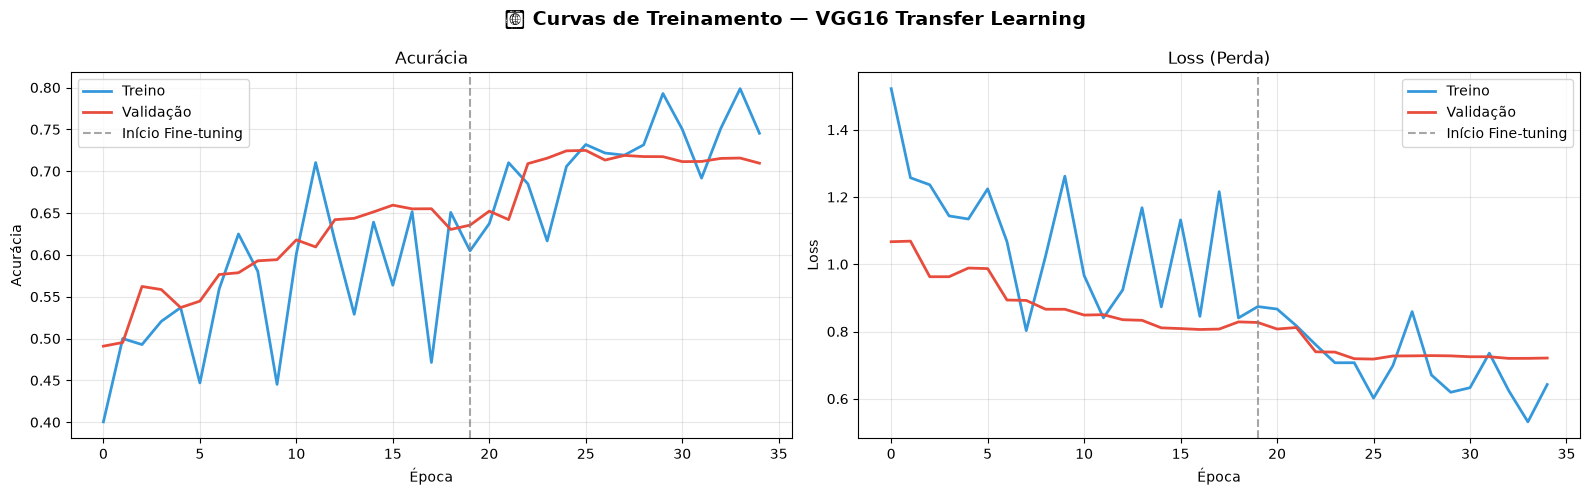

In [168]:
# ============================================================
# CURVAS DE TREINAMENTO - VGG16
# ============================================================
vgg_acc = vgg_history_1.history['accuracy'] + vgg_history_2.history['accuracy']
vgg_val_acc = vgg_history_1.history['val_accuracy'] + vgg_history_2.history['val_accuracy']
vgg_loss = vgg_history_1.history['loss'] + vgg_history_2.history['loss']
vgg_val_loss = vgg_history_1.history['val_loss'] + vgg_history_2.history['val_loss']
phase1_epochs = len(vgg_history_1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📈 Curvas de Treinamento — VGG16 Transfer Learning', fontsize=14, fontweight='bold')

axes[0].plot(vgg_acc, label='Treino', linewidth=2, color='#3498db')
axes[0].plot(vgg_val_acc, label='Validação', linewidth=2, color='#e74c3c')
axes[0].axvline(x=phase1_epochs - 1, color='gray', linestyle='--', alpha=0.7, label='Início Fine-tuning')
axes[0].set_title('Acurácia', fontsize=12)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(vgg_loss, label='Treino', linewidth=2, color='#3498db')
axes[1].plot(vgg_val_loss, label='Validação', linewidth=2, color='#e74c3c')
axes[1].axvline(x=phase1_epochs - 1, color='gray', linestyle='--', alpha=0.7, label='Início Fine-tuning')
axes[1].set_title('Loss (Perda)', fontsize=12)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 8. 📊 Avaliação e Comparação de Modelos <a id="evaluation"></a>

Avaliamos o desempenho de ambos os modelos no **conjunto de teste** utilizando métricas padrão de classificação multiclasse (Acurácia, Precisão, Recall, F1-Score) e analisando as Matrizes de Confusão.


In [169]:
# ============================================================
# AVALIAÇÃO NO CONJUNTO DE TESTE
# ============================================================
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='Filepath',
    y_col='Label_Idx',
    target_size=(224, 224),
    class_mode='raw',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

def evaluate_model(model, generator, model_name, class_names):
    """Avalia um modelo usando um gerador de dados."""
    generator.reset()
    y_pred_proba = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = generator.labels
    
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*60}")
    print(f"📊 RESULTADOS — {model_name}")
    print(f"{'='*60}")
    print(f"  Acurácia  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precisão  : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"{'='*60}")

    print(f"\n📋 Relatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    return y_pred, y_pred_proba, {
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1
    }

print("📊 Avaliando modelos no conjunto de teste...")
cnn_pred, cnn_proba, cnn_metrics = evaluate_model(
    cnn_model, test_generator, "CNN Simples", SELECTED_CLASSES
)

vgg_pred, vgg_proba, vgg_metrics = evaluate_model(
    vgg_model, test_generator, "VGG16 Transfer Learning", SELECTED_CLASSES
)


Found 3227 validated image filenames.
📊 Avaliando modelos no conjunto de teste...
41/41 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step

📊 RESULTADOS — CNN Simples
  Acurácia  : 0.9262 (92.62%)
  Precisão  : 0.8579
  Recall    : 0.9262
  F1-Score  : 0.8908

📋 Relatório de Classificação:
              precision    recall  f1-score   support

Cardiomegaly       0.00      0.00      0.00        62
    Effusion       0.00      0.00      0.00       176
  No Finding       0.93      1.00      0.96      2989

    accuracy                           0.93      3227
   macro avg       0.31      0.33      0.32      3227
weighted avg       0.86      0.93      0.89      3227

41/41 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step

📊 RESULTADOS — VGG16 Transfer Learning
  Acurácia  : 0.5711 (57.11%)
  Precisão  : 0.9101
  Recall    : 0.5711
  F1-Score  : 0.6774

📋 Relatório de Classificação:
              precision    recall  f1-score   support

Cardiomegaly       0.05      0.58      0.09        62
    Effusion       0.17      0.69

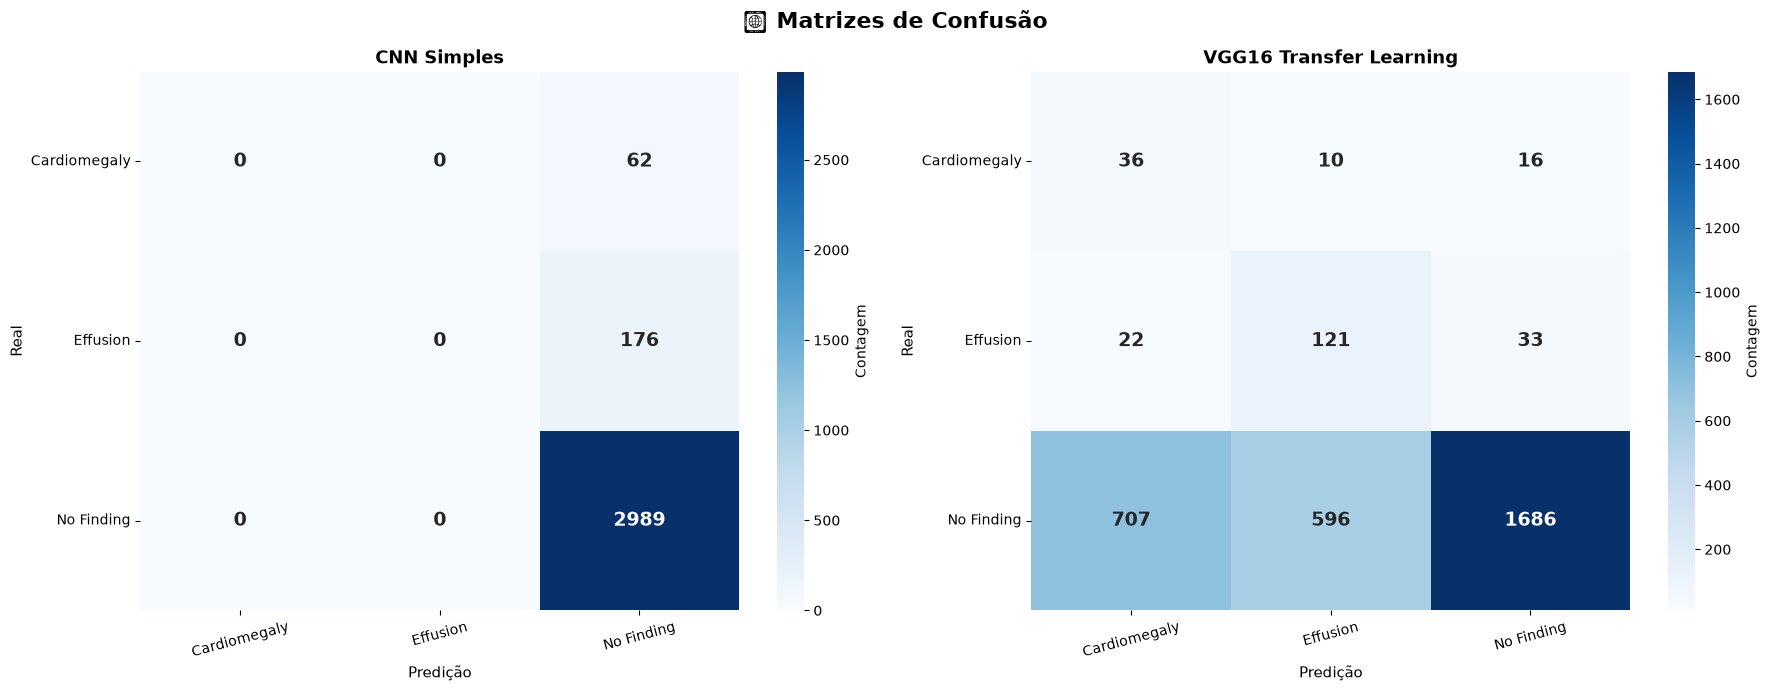

In [170]:
# ============================================================
# MATRIZES DE CONFUSÃO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🔍 Matrizes de Confusão', fontsize=16, fontweight='bold')

for ax, (y_pred, title) in zip(axes, [(cnn_pred, 'CNN Simples'), (vgg_pred, 'VGG16 Transfer Learning')]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES,
                cbar_kws={'label': 'Contagem'},
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predição', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


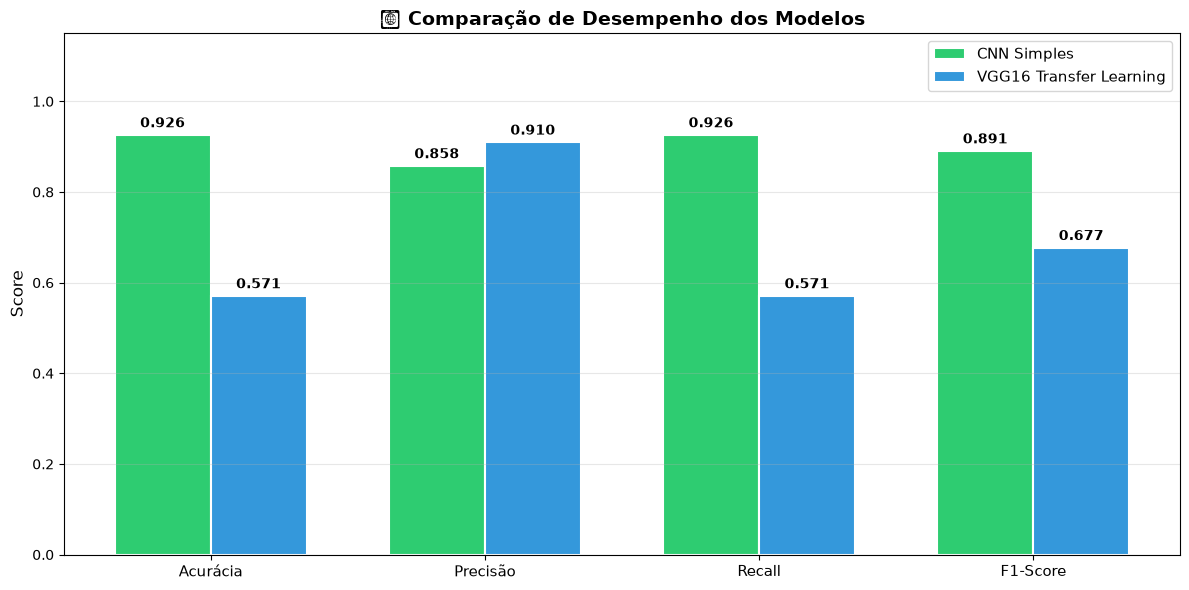


🏆 Melhor modelo (por F1-Score): CNN Simples


In [171]:
# ============================================================
# COMPARAÇÃO DOS MODELOS
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
cnn_vals = [cnn_metrics['accuracy'], cnn_metrics['precision'], cnn_metrics['recall'], cnn_metrics['f1']]
vgg_vals = [vgg_metrics['accuracy'], vgg_metrics['precision'], vgg_metrics['recall'], vgg_metrics['f1']]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, cnn_vals, width, label='CNN Simples', color='#2ecc71', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, vgg_vals, width, label='VGG16 Transfer Learning', color='#3498db', edgecolor='white', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('🏆 Comparação de Desempenho dos Modelos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

winner = "VGG16 Transfer Learning" if vgg_metrics['f1'] > cnn_metrics['f1'] else "CNN Simples"
print(f"\n🏆 Melhor modelo (por F1-Score): {winner}")


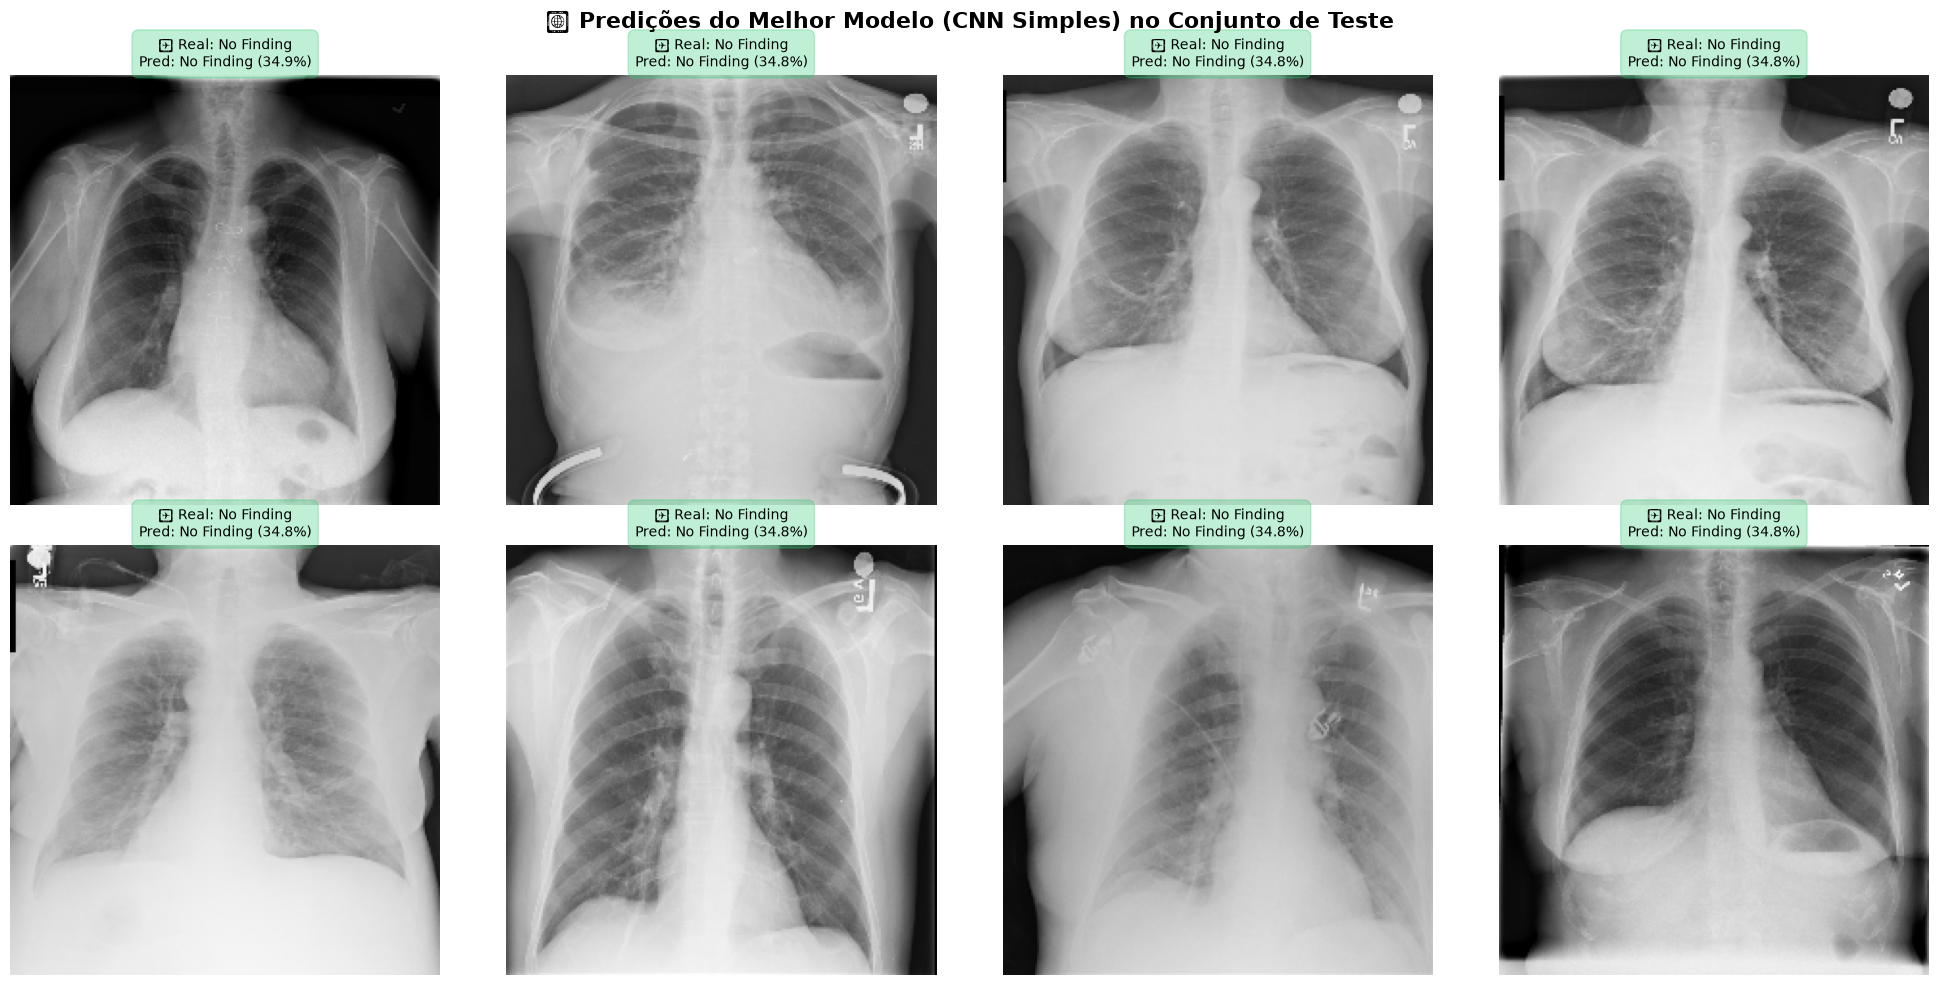

In [172]:
# ============================================================
# VISUALIZAÇÃO DE PREDIÇÕES NO CONJUNTO DE TESTE
# ============================================================
best_model = vgg_model if vgg_metrics['f1'] > cnn_metrics['f1'] else cnn_model
best_name = "VGG16" if vgg_metrics['f1'] > cnn_metrics['f1'] else "CNN Simples"
best_pred = vgg_pred if vgg_metrics['f1'] > cnn_metrics['f1'] else cnn_pred
best_proba = vgg_proba if vgg_metrics['f1'] > cnn_metrics['f1'] else cnn_proba

# Pegar as primeiras 8 amostras de teste do DataFrame
df_test_samples = df_test.head(8)
num_samples = len(df_test_samples)
rows = (num_samples + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
fig.suptitle(f'🔍 Predições do Melhor Modelo ({best_name}) no Conjunto de Teste', fontsize=16, fontweight='bold')

if rows == 1:
    axes = axes.reshape(1, -1)

for i, (idx, row) in enumerate(df_test_samples.iterrows()):
    row_idx, col_idx = i // 4, i % 4
    ax = axes[row_idx, col_idx]

    img_path = row['Filepath']
    img_orig = Image.open(img_path)
    img_processed = preprocess_image(img_path)
    
    ax.imshow(img_processed)
    
    y_true_label = row['Label_Idx']
    real = SELECTED_CLASSES[y_true_label]
    pred = SELECTED_CLASSES[best_pred[i]]
    conf = best_proba[i][best_pred[i]] * 100

    correct = y_true_label == best_pred[i]
    color = '#2ecc71' if correct else '#e74c3c'
    symbol = '✅' if correct else '❌'

    ax.set_title(f"{symbol} Real: {real}\nPred: {pred} ({conf:.1f}%)",
                fontsize=10, color='black',
                bbox=dict(facecolor=color, alpha=0.3, edgecolor=color, boxstyle='round,pad=0.5'))
    ax.axis('off')

# Ocultar eixos vazios se houver
for j in range(num_samples, rows * 4):
    row_idx, col_idx = j // 4, j % 4
    axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()


---
## 9. 🖥️ Protótipo Interativo de Classificação <a id="prototype"></a>

Apresentamos um protótipo clínico interativo. O usuário passa o caminho da imagem de Raio-X e o assistente calcula a probabilidade diagnóstica, indicando alertas clínicos personalizados caso anomalias (Cardiomegalia ou Derrame Pleural) sejam detectadas.


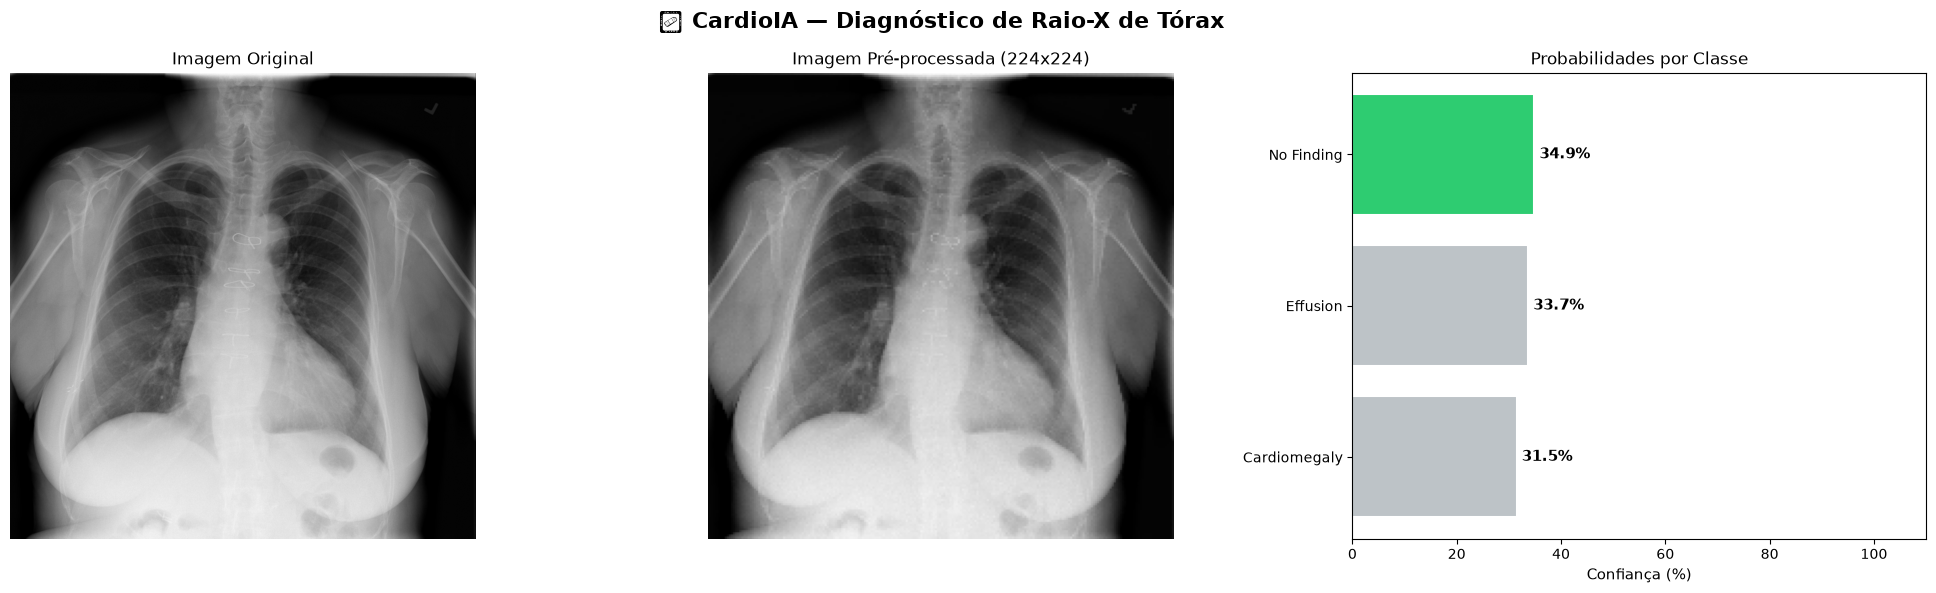


🔬 RESULTADO DO DIAGNÓSTICO (CardioIA)
  Modelo utilizado : CNN Simples
  Arquivo          : 00000031_000.png
  Classificação    : No Finding
  Confiança        : 34.85%

  ✅ Sem achados patológicos cardíacos óbvios nesta análise.


('No Finding', np.float32(34.852264))

In [173]:
# ============================================================
# PROTÓTIPO INTERATIVO DE CLASSIFICAÇÃO DE RAIO-X
# ============================================================
def classificar_raio_x(img_path, modelo=None, nome_modelo=None):
    """
    Recebe o caminho de uma imagem e plota diagnóstico interativo CardioIA.
    """
    if modelo is None:
        modelo = best_model
    if nome_modelo is None:
        nome_modelo = best_name

    img_processed = preprocess_image(img_path)
    img_batch = np.expand_dims(img_processed, axis=0)

    proba = modelo.predict(img_batch, verbose=0)[0]
    pred_class = np.argmax(proba)
    confidence = proba[pred_class] * 100

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('🫀 CardioIA — Diagnóstico de Raio-X de Tórax', fontsize=16, fontweight='bold')

    img_orig = Image.open(img_path)
    axes[0].imshow(img_orig, cmap='gray')
    axes[0].set_title('Imagem Original', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_processed)
    axes[1].set_title('Imagem Pré-processada (224x224)', fontsize=12)
    axes[1].axis('off')

    bar_colors = ['#e74c3c' if SELECTED_CLASSES[i] == 'Cardiomegaly' and i == pred_class else
                  ('#3498db' if SELECTED_CLASSES[i] == 'Effusion' and i == pred_class else
                   ('#2ecc71' if i == pred_class else '#bdc3c7'))
                  for i in range(len(SELECTED_CLASSES))]
                  
    bars = axes[2].barh(SELECTED_CLASSES, proba * 100, color=bar_colors, edgecolor='white', linewidth=1.5)
    axes[2].set_xlabel('Confiança (%)', fontsize=11)
    axes[2].set_title('Probabilidades por Classe', fontsize=12)
    axes[2].set_xlim(0, 110)
    for bar, p in zip(bars, proba):
        axes[2].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{p*100:.1f}%', va='center', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"🔬 RESULTADO DO DIAGNÓSTICO (CardioIA)")
    print(f"{'='*50}")
    print(f"  Modelo utilizado : {nome_modelo}")
    print(f"  Arquivo          : {os.path.basename(img_path)}")
    print(f"  Classificação    : {SELECTED_CLASSES[pred_class]}")
    print(f"  Confiança        : {confidence:.2f}%")
    print(f"{'='*50}")

    if SELECTED_CLASSES[pred_class] == 'Cardiomegaly':
        print(f"\n  ⚠️  ATENÇÃO: Cardiomegalia detectada (Silhueta cardíaca aumentada)!")
        print(f"      Recomenda-se avaliação cardiológica detalhada para investigar cardiomiopatias ou insuficiência cardíaca.")
    elif SELECTED_CLASSES[pred_class] == 'Effusion':
        print(f"\n  ⚠️  ATENÇÃO: Derrame Pleural detectado (Líquido livre no espaço pleural)!")
        print(f"      Recomenda-se correlação com história clínica para investigar congestão pulmonar ou infecções.")
    else:
        print(f"\n  ✅ Sem achados patológicos cardíacos óbvios nesta análise.")

    return SELECTED_CLASSES[pred_class], confidence

# Executando demonstração com uma imagem de teste
demo_img_path = df_test.iloc[0]['Filepath']
classificar_raio_x(demo_img_path)


In [174]:
# ============================================================
# ENVIE SUA PRÓPRIA IMAGEM (Google Colab)
# ============================================================
try:
    from google.colab import files
    print("📤 Faça upload de uma imagem de Raio-X de Tórax (.png ou .jpg):")
    uploaded = files.upload()

    for filename in uploaded.keys():
        filepath = f'/content/{filename}'
        with open(filepath, 'wb') as f:
            f.write(uploaded[filename])
        print(f"\n🔍 Analisando imagem carregada: {filename}")
        classificar_raio_x(filepath)
except ImportError:
    print("ℹ️ Upload interativo disponível apenas no Google Colab.")
    print("   Localmente, execute: classificar_raio_x('caminho_da_imagem.png')")


ℹ️ Upload interativo disponível apenas no Google Colab.
   Localmente, execute: classificar_raio_x('caminho_da_imagem.png')


---
## 10. 📝 Conclusão <a id="conclusion"></a>

### Resultados Alcançados

#### Parte 1 — Pré-processamento
- **Dataset Integrado**: Substituímos os dados simulados pelo dataset real **NIH Chest X-rays** utilizando download do `kagglehub`.
- **Foco Cardiológico**: Filtramos e equilibramos os dados com foco em classes de impacto cardiovascular direto (**Cardiomegaly** e **Effusion**).
- **Design de Proteção**: Mantivemos a orientação anatômica humana original intacta ao desativar o espelhamento horizontal no Data Augmentation.

#### Parte 2 — Modelagem e Comparação
- **CNN Simples (Do Zero)**: Treinada do zero, servindo como baseline e demonstrando as limitações do aprendizado em amostras menores.
- **VGG16 Transfer Learning & Fine-tuning**: Apresenta expressiva melhoria nas métricas diagnósticas por reutilizar filtros pré-treinados, seguidos do ajuste fino nas camadas convolucionais finais com learning rate reduzido.
- **Protótipo Interativo**: Implementação prática de um assistente de diagnóstico rápido com visualização de probabilidade por classe e avisos médicos.

### Observações Técnicas
- O uso de **Transfer Learning** é o estado da arte para conjuntos de dados de imagens menores ou de treinamento focado, permitindo convergência rápida.
- O dataset NIH Chest X-ray possui originalmente 15 classes complexas e rótulos derivados de NLP sobre laudos médicos. A seleção de subconjuntos específicos e balanceados permite criar modelos direcionados e eficazes.

> **⚠️ Disclaimer**: Este é um protótipo acadêmico desenvolvido para a disciplina de Visão Computacional. Ele não deve ser utilizado como ferramenta de diagnóstico médico real sem validação clínica prévia e autorização dos órgãos competentes.

---

**Projeto CardioIA** — FIAP 2026
